# Team ZeroTrustAI — Equal Voice, Verified by Peers

This is the organisers' Day 2 notebook with the `🔧 YOUR TURN` hooks filled in. Everything our Writeup claims is
computed below; nothing is hard-coded.

What we changed, and only this:
1. **One line in `run_fl`** (Section 4): it reseeds at the start of every run, so "before" and "after" share the same
   initial weights and batch order, and every comparison can be repeated over 5 seeds.
2. **One aggregation function, `make_agg`**, used for *both* tracks through the provided `agg_fn` hook.

The model (`WeakMLP`, 8 hidden units), local training, rounds, data split and attack code are untouched.

# CAIRLab Hackathon — Day 2 Extension: Intermediate + Advanced Tracks

Two new tracks unlock today, and you're free to attempt either or both between now and the
submission deadline:

| Track | Goal |
|---|---|
| 🟡 Intermediate | Client data is realistically **skewed** across the five banks — naive FedAvg performs worse under this skew. Fix the **aggregation**. |
| 🔴 Advanced (optional) | Partway through, one bank turns malicious and sends sabotaged updates. **Detect or resist** the attack. |

This notebook is self-contained — it rebuilds the dataset, partitions, model, and FL harness
from scratch, so you don't need yesterday's notebook open. The ideas carry over directly:
same story, same weak baseline, same FedAvg loop as Day 1, extended with what you need for
today's tracks.

**Scoring today:** unlike Day 1, these tracks aren't on a Kaggle leaderboard — a static
prediction file can't capture "how your aggregation holds up under skew" or "how much F1 your
defense recovers under attack." Instead, you'll report your before/after comparison in your
Kaggle Writeup, and export your final model for the organizers to spot-check. See the
Evaluation Rubric on the hackathon page for exact scoring weights.


## 0. Setup

In [1]:

# (pip --upgrade removed: using the preinstalled versions keeps the numbers reproducible)
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import copy, json, os, hashlib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

os.makedirs("data", exist_ok=True)
print("Setup complete.")


Setup complete.


## 1. Load and clean the dataset (same as Day 1)


In [2]:

TRAIN_URL = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt"
TEST_URL  = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest%2B.txt"

COLS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty",
]

# use the repo's local copy if present (identical files), else download
if os.path.exists("data/KDDTrain+.txt"): TRAIN_URL, TEST_URL = "data/KDDTrain+.txt", "data/KDDTest+.txt"
train_raw = pd.read_csv(TRAIN_URL, names=COLS)
test_raw  = pd.read_csv(TEST_URL, names=COLS)

def clean(df):
    df = df.drop(columns=["difficulty"]).copy()
    df["binary_label"] = (df["label"] != "normal").astype(int)
    return df

train_df = clean(train_raw)
test_df  = clean(test_raw)

CAT_COLS = ["protocol_type", "service", "flag"]
encoders = {}
for c in CAT_COLS:
    le = LabelEncoder()
    le.fit(pd.concat([train_df[c], test_df[c]], axis=0))
    train_df[c] = le.transform(train_df[c])
    test_df[c]  = le.transform(test_df[c])
    encoders[c] = le

FEATURE_COLS = [c for c in train_df.columns if c not in ["label", "binary_label"]]

scaler = StandardScaler()
train_df[FEATURE_COLS] = scaler.fit_transform(train_df[FEATURE_COLS])
test_df[FEATURE_COLS]  = scaler.transform(test_df[FEATURE_COLS])

print("features:", len(FEATURE_COLS))


features: 41


## 2. Partition into 5 clients — IID (for reference) and non-IID (today's data)

Same holdout reservation logic as Day 1 (same seed, so it's the identical reserved rows —
this doesn't matter for today's scoring, it's just kept consistent).

Today you also get a **non-IID** partition: the same pool of training rows, but split so
each "bank" sees a skewed slice of traffic — one might see mostly denial-of-service attacks,
another almost entirely normal traffic. This is realistic (different banks see different
customers and attackers), and it's what breaks naive FedAvg.


In [3]:

N_CLIENTS = 5
HOLDOUT_SIZE = 15000

_rng = np.random.RandomState(SEED)
_perm = _rng.permutation(len(train_df))
_holdout_idx = _perm[:HOLDOUT_SIZE]
_pool_idx = _perm[HOLDOUT_SIZE:]
train_pool = train_df.iloc[_pool_idx].reset_index(drop=True)

def make_iid_partition(df, n_clients=N_CLIENTS, seed=SEED):
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(df))
    chunks = np.array_split(idx, n_clients)
    return [df.iloc[c].reset_index(drop=True) for c in chunks]

FAMILY_MAP = {
    "normal": "normal",
    "neptune": "dos", "back": "dos", "land": "dos", "pod": "dos", "smurf": "dos",
    "teardrop": "dos", "apache2": "dos", "udpstorm": "dos", "processtable": "dos",
    "worm": "dos", "mailbomb": "dos",
    "satan": "probe", "ipsweep": "probe", "nmap": "probe", "portsweep": "probe",
    "mscan": "probe", "saint": "probe",
}

def make_noniid_partition(df, n_clients=N_CLIENTS, alpha=0.3, seed=SEED):
    '''Dirichlet-skewed split by attack family. Low alpha = strong skew.'''
    rng = np.random.RandomState(seed)
    df = df.copy()
    df["family"] = df["label"].map(lambda x: FAMILY_MAP.get(x, "r2l_u2r_other"))
    client_indices = [[] for _ in range(n_clients)]
    for fam in df["family"].unique():
        fam_idx = df.index[df["family"] == fam].to_numpy().copy()
        rng.shuffle(fam_idx)
        proportions = rng.dirichlet(alpha=[alpha] * n_clients)
        split_points = (np.cumsum(proportions) * len(fam_idx)).astype(int)[:-1]
        for i, s in enumerate(np.split(fam_idx, split_points)):
            client_indices[i].extend(s.tolist())
    out = []
    for ci in client_indices:
        rng.shuffle(ci)
        out.append(df.loc[ci].drop(columns=["family"]).reset_index(drop=True))
    return out

iid_clients = make_iid_partition(train_pool)
noniid_clients = make_noniid_partition(train_pool)

print("IID sizes:", [len(c) for c in iid_clients])
print("\\nNon-IID sizes:", [len(c) for c in noniid_clients])
for i, c in enumerate(noniid_clients):
    print(f"  client {i} label mix:", c["binary_label"].value_counts(normalize=True).round(2).to_dict())


IID sizes: [22195, 22195, 22195, 22194, 22194]
\nNon-IID sizes: [6272, 10658, 48219, 23239, 22585]
  client 0 label mix: {1: 0.81, 0: 0.19}
  client 1 label mix: {1: 0.86, 0: 0.14}
  client 2 label mix: {1: 0.68, 0: 0.32}
  client 3 label mix: {0: 0.85, 1: 0.15}
  client 4 label mix: {0: 0.96, 1: 0.04}


## 3. The weak baseline model (same as Day 1)


In [4]:

N_FEATURES = len(FEATURE_COLS)

class WeakMLP(nn.Module):
    def __init__(self, n_features=N_FEATURES, hidden=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


## 4. The FL harness — extended with robust aggregation and attack simulation

Same local training and FedAvg as Day 1, plus what today's tracks need: a
`coordinate_median` robust-aggregation baseline, a `custom` aggregation hook, and the
ability to simulate malicious clients.


In [5]:

X_test = torch.tensor(test_df[FEATURE_COLS].values, dtype=torch.float32)
y_test = torch.tensor(test_df["binary_label"].values, dtype=torch.float32)

def df_to_tensors(df):
    X = torch.tensor(df[FEATURE_COLS].values, dtype=torch.float32)
    y = torch.tensor(df["binary_label"].values, dtype=torch.float32)
    return X, y

def local_train(model, X, y, epochs=1, lr=0.05, batch_size=256):
    model = copy.deepcopy(model)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    n = len(X)
    for _ in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(X[idx]), y[idx])
            loss.backward()
            opt.step()
    return model

def get_flat_params(model):
    return torch.cat([p.data.view(-1) for p in model.parameters()])

def set_flat_params(model, flat):
    i = 0
    for p in model.parameters():
        n = p.numel()
        p.data.copy_(flat[i:i + n].view(p.shape))
        i += n

def fedavg(models, weights):
    weights = np.array(weights, dtype=float) / np.sum(weights)
    flats = torch.stack([get_flat_params(m) for m in models])
    avg = (flats * torch.tensor(weights, dtype=torch.float32).unsqueeze(1)).sum(dim=0)
    out = copy.deepcopy(models[0])
    set_flat_params(out, avg)
    return out

def coordinate_median(models):
    '''A simple robust-aggregation baseline: take the per-coordinate median of all
    client updates instead of the (weighted) mean. Outliers (e.g. a poisoned update
    with an inflated magnitude) influence the median far less than the mean.'''
    flats = torch.stack([get_flat_params(m) for m in models])
    med = flats.median(dim=0).values
    out = copy.deepcopy(models[0])
    set_flat_params(out, med)
    return out

def evaluate(model):
    model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(model(X_test)) > 0.5).float()
    return {
        "precision": round(precision_score(y_test, preds, zero_division=0), 4),
        "recall": round(recall_score(y_test, preds, zero_division=0), 4),
        "f1": round(f1_score(y_test, preds, zero_division=0), 4),
    }

def run_fl(client_dfs, model_fn=lambda: WeakMLP(), rounds=8, epochs=1,
           aggregation="fedavg", agg_fn=None,
           malicious_clients=None, attack="scale", scale_factor=15.0, verbose=True, seed=SEED):
    '''
    aggregation: "fedavg" | "median" | "custom" (use agg_fn for "custom")
    malicious_clients: list of client indices that send poisoned updates (advanced track)
    attack: "label_flip" or "scale" (scale = label_flip + inflated update magnitude)
    '''
    torch.manual_seed(seed)  # OUR ONLY HARNESS CHANGE: every run starts from the same initial weights and
                             # batch order, so before/after differences come from aggregation alone
    malicious_clients = malicious_clients or []
    global_model = model_fn()
    client_tensors = [df_to_tensors(df) for df in client_dfs]

    history = []
    for r in range(rounds):
        local_models, sizes = [], []
        global_flat = get_flat_params(global_model)

        for cid, (X, y) in enumerate(client_tensors):
            is_malicious = cid in malicious_clients
            if is_malicious:
                y = 1 - y  # label-flip
            lm = local_train(global_model, X, y, epochs=epochs)
            if is_malicious and attack == "scale":
                delta = get_flat_params(lm) - global_flat
                set_flat_params(lm, global_flat + scale_factor * delta)
            local_models.append(lm)
            sizes.append(len(X))

        prev_global_model = global_model
        if aggregation == "fedavg":
            global_model = fedavg(local_models, sizes)
        elif aggregation == "median":
            global_model = coordinate_median(local_models)
        elif aggregation == "custom":
            global_model = agg_fn(local_models, sizes, prev_global_model)
        else:
            raise ValueError(f"unknown aggregation: {aggregation}")

        metrics = evaluate(global_model)
        history.append(metrics)
        if verbose:
            print(f"round {r+1:>2}: {metrics}")

    return global_model, history


## 5. Recompute your Day 1 reference point

Quick reference run on IID data — same as your Day 1 baseline — so you have a same-session
number to compare today's non-IID results against.


In [6]:

print("Reference: weak model, IID clients, naive FedAvg")
baseline_model, baseline_history = run_fl(iid_clients, rounds=6)
print("\\nFinal:", baseline_history[-1])


Reference: weak model, IID clients, naive FedAvg


round  1: {'precision': 0.9574, 'recall': 0.2875, 'f1': 0.4423}
round  2: {'precision': 0.9695, 'recall': 0.6026, 'f1': 0.7432}
round  3: {'precision': 0.9694, 'recall': 0.628, 'f1': 0.7622}


round  4: {'precision': 0.9315, 'recall': 0.6348, 'f1': 0.7551}
round  5: {'precision': 0.9324, 'recall': 0.6413, 'f1': 0.7599}
round  6: {'precision': 0.9324, 'recall': 0.6473, 'f1': 0.7641}
\nFinal: {'precision': 0.9324, 'recall': 0.6473, 'f1': 0.7641}


---
## 🟡 Intermediate track — fix the non-IID aggregation

Switch to the skewed client split and watch what happens with plain FedAvg.


In [7]:

print("Non-IID clients, naive FedAvg (same model, same aggregation as baseline)")
noniid_model, noniid_history = run_fl(noniid_clients, rounds=8)
print("\\nIID F1:    ", baseline_history[-1]["f1"])
print("Non-IID F1:", noniid_history[-1]["f1"])


Non-IID clients, naive FedAvg (same model, same aggregation as baseline)


round  1: {'precision': 0.9858, 'recall': 0.2063, 'f1': 0.3412}
round  2: {'precision': 0.9863, 'recall': 0.5166, 'f1': 0.678}


round  3: {'precision': 0.9436, 'recall': 0.5359, 'f1': 0.6836}


round  4: {'precision': 0.9374, 'recall': 0.5484, 'f1': 0.692}
round  5: {'precision': 0.9371, 'recall': 0.5554, 'f1': 0.6974}


round  6: {'precision': 0.9383, 'recall': 0.5625, 'f1': 0.7034}


round  7: {'precision': 0.9408, 'recall': 0.5662, 'f1': 0.7069}
round  8: {'precision': 0.9524, 'recall': 0.5681, 'f1': 0.7117}
\nIID F1:     0.7641
Non-IID F1: 0.7117


Naive FedAvg treats every client's update as equally trustworthy and just weights by
data size. When one client's local distribution is very different from the global
distribution (e.g. almost-all-attack-traffic), its update can pull the global model in a
direction that hurts everyone else.

**Ideas to improve aggregation**, roughly in order of effort:
- Weight clients differently — e.g. down-weight clients whose local class distribution is
  most different from the (estimated) global distribution.
- **FedProx-style**: add a proximal penalty term in local training that keeps each client's
  local model from drifting too far from the current global model.
- Cluster clients by similarity of their updates and aggregate within clusters before a
  final merge.

**Your hook:** write a function with signature
`agg_fn(local_models, sizes, prev_global_model) -> model` and pass it to
`run_fl(..., aggregation="custom", agg_fn=my_agg_fn)`.


### Our aggregator (used for both tracks)

Each round, for every bank we take its **update** `delta_i = local weights − previous global weights`.

| Step | What | Why |
|---|---|---|
| 1. Normalise | divide each update by the bank's number of local SGD steps | a bank with 8x the rows takes 8x the steps, so its raw update is longer for no good reason (FedNova, Wang et al. 2020) |
| 2. Size check | flag a bank whose normalised update is more than **5x** the median length | scaling is unmistakable once step counts are removed: honest banks stay under 2.7x, the 15x attacker is at 19x or more |
| 3. **Peer check** | every bank scores every candidate model on a 2,000-row sample of its *own private data* and returns one number (AUC). A bank whose model ranks attacks **worse than a coin flip (median AUC < 0.5)** is quarantined | label flipping does not change an update's size, and its *direction* is indistinguishable from an honest bank with unusual data. But a flipped model is wrong on *everyone's* data, while an honest minority bank's model is still right |
| 4. Average | **equal-weight** mean of the survivors, rescaled by their mean step count | one bank, one voice: the consortium wants a detector that works for the average *bank*, not the average *row* |

No clipping: we measured that clipping survivors throttles the one honest attack-heavy bank left after the attacker
is removed (see the ablation below).

The peer check uses no server-side data and its only threshold is chance level. In the simulation, malicious banks
**lie as validators** in the worst way (they score honest banks 0 and each other 1); the median over voters absorbs
that as long as honest banks are the majority.

In [8]:
# 🔧 OUR TURN — one aggregator for both tracks
from sklearn.metrics import roc_auc_score
LOCAL_BATCH = 256   # local_train's batch size; a bank's step count is a public function of its row count

def bank_validation_samples(client_dfs, n=2000, seed=0):
    """Each bank holds a small labelled sample of ITS OWN data to score candidate models with.
    Only one number per candidate ever leaves the bank."""
    rng = np.random.RandomState(seed); out = []
    for df in client_dfs:
        X, y = df_to_tensors(df.iloc[rng.choice(len(df), min(n, len(df)), replace=False)])
        out.append((X, y.numpy()))
    return out

def make_agg(validators=None, liars=(), norm_mult=5.0, normalize=True, equal=True, clip=None, log=None):
    """Returns agg_fn(local_models, sizes, prev_global_model) -> model.
    validators: per-bank private samples for the peer check (None switches the peer check off).
    liars:      SIMULATION ONLY - banks that vote dishonestly as validators (set to the malicious banks).
    normalize / equal / clip exist only so the ablations below can switch each ingredient off."""
    quarantined = set()
    def agg(local_models, sizes, prev_global_model):
        K = len(local_models); ref = get_flat_params(prev_global_model)
        d = torch.stack([get_flat_params(m) - ref for m in local_models])           # one update per bank
        tau = torch.tensor([float(np.ceil(n / LOCAL_BATCH)) for n in sizes])        # local SGD steps
        dn = d / tau.unsqueeze(1) if normalize else d                               # 1. normalise
        quar = torch.tensor([i in quarantined for i in range(K)])
        norms = dn.norm(dim=1); ratio = norms / norms[~quar].median()
        big = (ratio > norm_mult) & ~quar                                           # 2. size check
        score = torch.ones(K)
        if validators is not None:                                                  # 3. peer check
            A = np.zeros((K, K))                                                    # A[j, i]: bank j's score for bank i's model
            with torch.no_grad():
                for j, (Xj, yj) in enumerate(validators):
                    for i, m in enumerate(local_models):
                        A[j, i] = (1.0 if i in liars else 0.0) if j in liars else roc_auc_score(yj, np.nan_to_num(m(Xj).numpy()))
            voters = [j for j in range(K) if j not in quarantined]                  # quarantined banks lose their vote
            score = torch.tensor(np.median(A[voters], axis=0), dtype=torch.float32)
        harmful = (score < 0.5) & ~quar
        if (big | harmful | quar).sum() > K // 2: harmful[:] = False                # honest-majority assumption
        quarantined.update(i for i in range(K) if harmful[i])
        keep = ~(big | harmful | quar)
        if keep.sum() == 0: keep[:] = True
        if log is not None:
            log.append({"flagged": [i for i in range(K) if not keep[i]],
                        "size_ratio": [round(x, 1) for x in ratio.tolist()], "peer_auc": [round(x, 2) for x in score.tolist()]})
        if clip: dn = dn * torch.clamp(clip * norms[keep].median() / (norms + 1e-12), max=1.0).unsqueeze(1)
        if equal:                                                                   # 4. equal voice
            step = (tau[keep].mean() if normalize else 1.0) * dn[keep].mean(0)
        else:                                                                       # (ablation: size weights)
            w = torch.tensor(np.array(sizes, float), dtype=torch.float32)[keep]; w = w / w.sum()
            step = ((w * tau[keep]).sum() if normalize else 1.0) * (dn[keep] * w.unsqueeze(1)).sum(0)
        out = copy.deepcopy(prev_global_model); set_flat_params(out, ref + step)
        return out
    return agg

# ---- helpers for honest reporting: repeat every comparison over 5 seeds ----
SEEDS = [42, 0, 1, 2, 3]      # 42 is the notebook's own seed; it is also the run we export
VALID = bank_validation_samples(noniid_clients)
def multi_full(client_dfs, make_kw=lambda: {}, **kw):
    """One run per seed. Returns (array [seed, round] of test F1, list of final models)."""
    runs = [run_fl(client_dfs, seed=s, verbose=False, **make_kw(), **kw) for s in SEEDS]
    return np.array([[h["f1"] for h in hist] for _, hist in runs]), [m for m, _ in runs]
def multi(client_dfs, make_kw=lambda: {}, **kw): return multi_full(client_dfs, make_kw, **kw)[0]
def ms(a): return f"{a[:, -1].mean():.4f} ± {a[:, -1].std():.4f}"
def OURS(mal=(), **agg_kw): return lambda: dict(aggregation="custom", agg_fn=make_agg(VALID, liars=mal, **agg_kw))

print("Intermediate track, seed 42: non-IID clients, OUR aggregation")
my_agg_fn = make_agg(VALID)
custom_model, custom_history = run_fl(noniid_clients, rounds=8, aggregation="custom", agg_fn=my_agg_fn)
print("\nNaive non-IID F1 (BEFORE):", noniid_history[-1]["f1"])
print("Our aggregation F1 (AFTER):", custom_history[-1]["f1"], f"  (+{custom_history[-1]['f1'] - noniid_history[-1]['f1']:.4f})")

Intermediate track, seed 42: non-IID clients, OUR aggregation


round  1: {'precision': 0.9625, 'recall': 0.6655, 'f1': 0.7869}


round  2: {'precision': 0.925, 'recall': 0.6757, 'f1': 0.7809}


round  3: {'precision': 0.9234, 'recall': 0.6891, 'f1': 0.7892}


round  4: {'precision': 0.9217, 'recall': 0.686, 'f1': 0.7866}


round  5: {'precision': 0.9199, 'recall': 0.6836, 'f1': 0.7844}


round  6: {'precision': 0.9182, 'recall': 0.6823, 'f1': 0.7829}
round  7: {'precision': 0.9177, 'recall': 0.6823, 'f1': 0.7827}


round  8: {'precision': 0.9173, 'recall': 0.6816, 'f1': 0.7821}

Naive non-IID F1 (BEFORE): 0.7117
Our aggregation F1 (AFTER): 0.7821   (+0.0704)


### Intermediate: is the gain real? 5 seeds, ablations, and what did not work
A single run can flatter a method by ±0.01–0.02 here, so every row is mean ± std over 5 seeds.
AUC is threshold-free, so it shows whether the model *ranks* attacks better or merely shifted its cut-off.
The **in-distribution holdout** is the 15,000 training rows no bank ever sees.

In [9]:
X_hold, y_hold = df_to_tensors(train_df.iloc[_holdout_idx])
def extra(models):
    """Mean test AUC, test recall and in-distribution holdout F1 over the per-seed models."""
    auc, rec, hold = [], [], []
    for m in models:
        m.eval()
        with torch.no_grad(): lt, lh = m(X_test), m(X_hold)
        auc.append(roc_auc_score(y_test, lt)); rec.append(recall_score(y_test, (torch.sigmoid(lt) > 0.5).float()))
        hold.append(f1_score(y_hold, (torch.sigmoid(lh) > 0.5).float()))
    return np.mean(auc), np.mean(rec), np.mean(hold)

def fedavgm(beta):                      # tried: server momentum on the size-weighted average
    st = {"v": None}
    def agg(lm, sizes, prev):
        ref = get_flat_params(prev); w = torch.tensor(np.array(sizes, float) / sum(sizes), dtype=torch.float32)
        g = (torch.stack([get_flat_params(m) - ref for m in lm]) * w.unsqueeze(1)).sum(0)
        st["v"] = g if st["v"] is None else beta * st["v"] + g
        out = copy.deepcopy(prev); set_flat_params(out, ref + st["v"]); return out
    return agg
_plain_local_train = local_train
def local_train_prox(model, X, y, epochs=1, lr=0.05, batch_size=256, mu=0.1):   # tried: FedProx
    ref = [p.detach().clone() for p in model.parameters()]
    model = copy.deepcopy(model); opt = torch.optim.SGD(model.parameters(), lr=lr); loss_fn = nn.BCEWithLogitsLoss(); n = len(X)
    for _ in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]; opt.zero_grad()
            (loss_fn(model(X[idx]), y[idx]) + 0.5 * mu * sum(((p - r) ** 2).sum() for p, r in zip(model.parameters(), ref))).backward(); opt.step()
    return model
def local_train_balanced(model, X, y, epochs=1, lr=0.05, batch_size=256):       # tried: class-balanced local loss
    pw = (1 - y).sum() / y.sum().clamp(min=1)
    model = copy.deepcopy(model); opt = torch.optim.SGD(model.parameters(), lr=lr); loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw); n = len(X)
    for _ in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]; opt.zero_grad(); loss_fn(model(X[idx]), y[idx]).backward(); opt.step()
    return model

INT = {
    "Naive FedAvg (BEFORE)":                    multi_full(noniid_clients),
    "Coordinate median (provided)":             multi_full(noniid_clients, aggregation="median"),
    "Ours (AFTER)":                             multi_full(noniid_clients, OURS()),
    "  ablation: equal weights, no step norm":  multi_full(noniid_clients, OURS(normalize=False)),
    "  ablation: step norm, size weights":      multi_full(noniid_clients, OURS(equal=False)),
    "  ablation: ours + clip to median":        multi_full(noniid_clients, OURS(clip=1.0)),
    "  tried: FedAvgM, momentum 0.9":           multi_full(noniid_clients, lambda: dict(aggregation="custom", agg_fn=fedavgm(0.9))),
}
local_train = local_train_prox
INT["  tried: FedProx, mu 0.1"] = multi_full(noniid_clients)
local_train = local_train_balanced
INT["  tried: ours + class-balanced loss"] = multi_full(noniid_clients, OURS())
local_train = _plain_local_train
IID_NAIVE, IID_OURS = multi(iid_clients), multi(iid_clients, lambda: dict(aggregation="custom", agg_fn=make_agg(bank_validation_samples(iid_clients))))

print(f"{'Non-IID split, 8 rounds, 5 seeds':<40}{'test F1':>18}{'seed 42':>9}{'recall':>8}{'AUC':>8}{'holdout F1':>12}")
for k, (a, models) in INT.items():
    auc, rec, hold = extra(models); print(f"{k:<40}{ms(a):>18}{a[0, -1]:>9.4f}{rec:>8.3f}{auc:>8.3f}{hold:>12.4f}")
print(f"\n{'IID control: naive FedAvg':<40}{ms(IID_NAIVE):>18}\n{'IID control: ours':<40}{ms(IID_OURS):>18}")
b, o = INT["Naive FedAvg (BEFORE)"][0][:, -1], INT["Ours (AFTER)"][0][:, -1]
print(f"\nGain over naive: +{o.mean() - b.mean():.4f} (5-seed mean); ours wins on {int((o > b).sum())}/5 seeds; ours vs naive-on-IID: {o.mean() - IID_NAIVE[:, -1].mean():+.4f}")

# Why F1 rises: recall per attack family (mean of 5 seeds). Small banks 0 and 1 hold most of the rare families.
fam = test_df["label"].map(lambda x: FAMILY_MAP.get(x, "r2l_u2r_other")).values
def family_recall(models):
    out = {}
    for m in models:
        with torch.no_grad(): p = (torch.sigmoid(m(X_test)) > 0.5).numpy()
        for f in ["dos", "probe", "r2l_u2r_other", "normal"]:
            out.setdefault(f, []).append((p[fam == f] == (f != "normal")).mean())
    return {f: np.mean(v) for f, v in out.items()}
fn, fo = family_recall(INT["Naive FedAvg (BEFORE)"][1]), family_recall(INT["Ours (AFTER)"][1])
print(f"\n{'correctly classified, by traffic family':<42}{'naive':>8}{'ours':>8}   (test rows)")
for f, name in [("dos", "DoS attacks"), ("probe", "Probe attacks"), ("r2l_u2r_other", "R2L / U2R / unseen attacks"), ("normal", "Normal traffic")]:
    print(f"{name:<42}{fn[f]:>8.3f}{fo[f]:>8.3f}   ({(fam == f).sum()})")

# Does it hold on OTHER non-IID splits? Same training seed, 6 different Dirichlet partitions.
print(f"\n{'other partitions (alpha, partition seed)':<42}{'naive':>8}{'ours':>8}")
wins = 0
for alpha, pseed in [(0.3, 1), (0.3, 2), (0.3, 3), (0.1, 1), (1.0, 1), (1.0, 2)]:
    parts = [p for p in make_noniid_partition(train_pool, alpha=alpha, seed=pseed) if len(p) > 0]
    f_n = run_fl(parts, verbose=False)[1][-1]["f1"]
    f_o = run_fl(parts, verbose=False, aggregation="custom", agg_fn=make_agg(bank_validation_samples(parts)))[1][-1]["f1"]
    wins += f_o > f_n; print(f"{'alpha ' + str(alpha) + ', seed ' + str(pseed):<42}{f_n:>8.4f}{f_o:>8.4f}")
print(f"ours beats naive on {wins}/6 other partitions")
INT = {k: v[0] for k, v in INT.items()}

Non-IID split, 8 rounds, 5 seeds                   test F1  seed 42  recall     AUC  holdout F1
Naive FedAvg (BEFORE)                      0.7169 ± 0.0057   0.7117   0.574   0.882      0.9552
Coordinate median (provided)               0.7355 ± 0.0148   0.7489   0.601   0.903      0.9584
Ours (AFTER)                               0.7809 ± 0.0072   0.7821   0.679   0.920      0.9495
  ablation: equal weights, no step norm    0.7536 ± 0.0094   0.7541   0.634   0.910      0.9578
  ablation: step norm, size weights        0.7557 ± 0.0111   0.7640   0.636   0.903      0.9615


  ablation: ours + clip to median          0.7679 ± 0.0069   0.7626   0.656   0.915      0.9550
  tried: FedAvgM, momentum 0.9             0.7234 ± 0.0090   0.7387   0.588   0.726      0.9473
  tried: FedProx, mu 0.1                   0.7177 ± 0.0074   0.7064   0.578   0.894      0.9531
  tried: ours + class-balanced loss        0.7682 ± 0.0065   0.7711   0.650   0.920      0.9635

IID control: naive FedAvg                  0.7580 ± 0.0065
IID control: ours                          0.7580 ± 0.0065

Gain over naive: +0.0641 (5-seed mean); ours wins on 5/5 seeds; ours vs naive-on-IID: +0.0230

correctly classified, by traffic family      naive    ours   (test rows)
DoS attacks                                  0.775   0.779   (7460)
Probe attacks                                0.615   0.916   (2421)
R2L / U2R / unseen attacks                   0.033   0.231   (2952)
Normal traffic                               0.964   0.921   (9711)

other partitions (alpha, partition seed)     naive    o

alpha 0.3, seed 1                           0.7420  0.7904


alpha 0.3, seed 2                           0.7633  0.7779


/Users/kelvinackah/Desktop/projects/hackaton/secure-ai-competition/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/kelvinackah/Desktop/projects/hackaton/secure-ai-competition/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/kelvinackah/Desktop/projects/hackaton/secure-ai-competition/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/kelvinackah/Desktop/projects/hackaton/secure-ai-competition/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that

...

/Users/kelvinackah/Desktop/projects/hackaton/secure-ai-competition/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/kelvinackah/Desktop/projects/hackaton/secure-ai-competition/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/kelvinackah/Desktop/projects/hackaton/secure-ai-competition/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/kelvinackah/Desktop/projects/hackaton/secure-ai-competition/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that

/Users/kelvinackah/Desktop/projects/hackaton/secure-ai-competition/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/kelvinackah/Desktop/projects/hackaton/secure-ai-competition/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/kelvinackah/Desktop/projects/hackaton/secure-ai-competition/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/kelvinackah/Desktop/projects/hackaton/secure-ai-competition/.venv/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that

alpha 0.1, seed 1                           0.7245  0.8128


alpha 1.0, seed 1                           0.7277  0.7831


alpha 1.0, seed 2                           0.7173  0.7829
ours beats naive on 6/6 other partitions


---
## 🔴 Advanced track (optional) — detect or resist a poisoning attack

Partway through, imagine one of your five "banks" has been compromised (or is actively
malicious) and starts sending sabotaged updates instead of honest ones. Below, client `1`
is malicious: it flips its local labels **and** inflates the magnitude of its update so it
dominates a plain average, regardless of how much data it actually has.


In [10]:

print("Non-IID + 1 malicious client (scale attack), naive FedAvg — should degrade")
attacked_model, attacked_history = run_fl(
    noniid_clients, rounds=8,
    malicious_clients=[1], attack="scale", scale_factor=15.0,
)
print("\\nClean non-IID F1:  ", noniid_history[-1]["f1"])
print("Under attack F1:    ", attacked_history[-1]["f1"])


Non-IID + 1 malicious client (scale attack), naive FedAvg — should degrade
round  1: {'precision': 1.0, 'recall': 0.1038, 'f1': 0.1881}
round  2: {'precision': 0.9959, 'recall': 0.1128, 'f1': 0.2026}


round  3: {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
round  4: {'precision': 0.8421, 'recall': 0.0087, 'f1': 0.0173}
round  5: {'precision': 0.8779, 'recall': 0.0118, 'f1': 0.0232}


round  6: {'precision': 0.854, 'recall': 0.0337, 'f1': 0.0649}
round  7: {'precision': 0.9868, 'recall': 0.2497, 'f1': 0.3986}
round  8: {'precision': 0.0794, 'recall': 0.0376, 'f1': 0.0511}
\nClean non-IID F1:   0.7117
Under attack F1:     0.0511


In [11]:

print("Same attack, but aggregating with the coordinate-median baseline defense")
defended_model, defended_history = run_fl(
    noniid_clients, rounds=8,
    malicious_clients=[1], attack="scale", scale_factor=15.0,
    aggregation="median",
)
print("\\nUnder attack (naive FedAvg): ", attacked_history[-1]["f1"])
print("Under attack (median defense):", defended_history[-1]["f1"])


Same attack, but aggregating with the coordinate-median baseline defense


round  1: {'precision': 1.0, 'recall': 0.082, 'f1': 0.1515}
round  2: {'precision': 0.999, 'recall': 0.1514, 'f1': 0.263}


round  3: {'precision': 0.9991, 'recall': 0.4551, 'f1': 0.6253}


round  4: {'precision': 0.9953, 'recall': 0.4952, 'f1': 0.6614}
round  5: {'precision': 0.9884, 'recall': 0.5102, 'f1': 0.673}


round  6: {'precision': 0.988, 'recall': 0.5186, 'f1': 0.6802}


round  7: {'precision': 0.9878, 'recall': 0.5227, 'f1': 0.6837}
round  8: {'precision': 0.9875, 'recall': 0.525, 'f1': 0.6855}
\nUnder attack (naive FedAvg):  0.0511
Under attack (median defense): 0.6855


`coordinate_median` is given as a working baseline defense — notice it already recovers
some of the lost F1. That's your floor, not your ceiling. Try cranking `scale_factor` up
(e.g. 30–50) and/or adding a second malicious client (`malicious_clients=[1, 3]`) — at some
point naive FedAvg collapses to F1 ≈ 0. Then push the defense further:

- **Trimmed mean** — drop the top/bottom k updates per coordinate before averaging.
- **Norm clipping** — clip each client's update to a maximum L2 norm before aggregating.
- **Anomaly scoring / Krum-style selection** — score each client's update by similarity to
  the others, and aggregate only the most mutually-consistent subset.
- **Detection, not just robustness** — can you flag *which* client(s) are malicious?

**Your hook:** same as the intermediate track — write
`agg_fn(local_models, sizes, prev_global_model) -> model` and pass `aggregation="custom"`.


In [12]:
# 🔧 OUR TURN — advanced track: the SAME aggregator, with its detection log switched on.
# Bank 1 is malicious, so in the simulation it also lies as a validator (liars=[1]).
DETECTION_LOG = []
my_defense_fn = make_agg(VALID, liars=[1], log=DETECTION_LOG)
my_defense_model, my_defense_history = run_fl(
    noniid_clients, rounds=8,
    malicious_clients=[1], attack="scale", scale_factor=15.0,
    aggregation="custom", agg_fn=my_defense_fn,
)
print("\nNaive under attack (BEFORE):", attacked_history[-1]["f1"])
print("Median defense (provided):  ", defended_history[-1]["f1"])
print("Our defense (AFTER):        ", my_defense_history[-1]["f1"], f"  (recovered +{my_defense_history[-1]['f1'] - attacked_history[-1]['f1']:.4f})")
print("\nDetection log — the true attacker is bank 1:")
for r, row in enumerate(DETECTION_LOG, 1): print(f"  round {r}: excluded {row['flagged']}   size ratio {row['size_ratio']}   peer AUC {row['peer_auc']}")

round  1: {'precision': 0.9548, 'recall': 0.2552, 'f1': 0.4028}


round  2: {'precision': 0.9677, 'recall': 0.6279, 'f1': 0.7616}


round  3: {'precision': 0.9575, 'recall': 0.6503, 'f1': 0.7745}


round  4: {'precision': 0.9276, 'recall': 0.6648, 'f1': 0.7745}


round  5: {'precision': 0.9268, 'recall': 0.6734, 'f1': 0.78}


round  6: {'precision': 0.9255, 'recall': 0.6717, 'f1': 0.7784}


round  7: {'precision': 0.9249, 'recall': 0.6694, 'f1': 0.7767}


round  8: {'precision': 0.925, 'recall': 0.6684, 'f1': 0.776}

Naive under attack (BEFORE): 0.0511
Median defense (provided):   0.6855
Our defense (AFTER):         0.776   (recovered +0.7249)

Detection log — the true attacker is bank 1:
  round 1: excluded [1]   size ratio [1.7, 18.9, 0.7, 1.0, 1.0]   peer AUC [0.95, 0.11, 0.95, 0.93, 0.95]
  round 2: excluded [1]   size ratio [2.5, 39.2, 0.7, 1.0, 1.0]   peer AUC [0.97, 0.91, 0.98, 0.98, 0.98]
  round 3: excluded [1]   size ratio [2.7, 76.1, 0.6, 1.0, 1.0]   peer AUC [0.98, 0.89, 0.99, 0.99, 0.99]
  round 4: excluded [1]   size ratio [2.3, 102.6, 0.5, 1.0, 1.0]   peer AUC [0.98, 0.89, 0.99, 0.99, 0.99]
  round 5: excluded [1]   size ratio [2.5, 118.8, 0.5, 1.0, 1.0]   peer AUC [0.99, 0.9, 0.99, 0.99, 0.99]
  round 6: excluded [1]   size ratio [2.6, 134.5, 0.5, 1.0, 1.0]   peer AUC [0.99, 0.9, 0.99, 0.99, 0.99]
  round 7: excluded [1]   size ratio [2.3, 140.0, 0.5, 1.0, 1.0]   peer AUC [0.99, 0.91, 0.99, 0.99, 0.99]
  round 8: exclude

### Advanced: stress tests, 5 seeds each — including the case where we fail
Final F1 for naive FedAvg, the provided median, and ours. `caught` = attacker-rounds excluded / attacker-rounds;
`false flags` = honest bank-rounds wrongly excluded. Malicious banks always lie as validators.

In [13]:
SCENARIOS = {
    "no attacker (false-alarm check)":           dict(),
    "OFFICIAL: bank 1, flip + 15x scale":        dict(malicious_clients=[1], scale_factor=15.0),
    "bank 1, flip + 50x scale":                  dict(malicious_clients=[1], scale_factor=50.0),
    "bank 1, flip + 2x (under the size check)":  dict(malicious_clients=[1], scale_factor=2.0),
    "bank 1, flip only (no scaling)":            dict(malicious_clients=[1], attack="label_flip"),
    "bank 0 (smallest), flip only":              dict(malicious_clients=[0], attack="label_flip"),
    "bank 2 (largest), flip only":               dict(malicious_clients=[2], attack="label_flip"),
    "banks 1+3, flip + 15x scale":               dict(malicious_clients=[1, 3], scale_factor=15.0),
    "banks 1+3, flip only (colluding)":          dict(malicious_clients=[1, 3], attack="label_flip"),
    "banks 0+1, flip only (both attack-heavy)":  dict(malicious_clients=[0, 1], attack="label_flip"),
    "OFFICIAL attack, 16 rounds":                dict(malicious_clients=[1], scale_factor=15.0, rounds=16),
    "banks 1+3+4, flip only (MALICIOUS MAJORITY)": dict(malicious_clients=[1, 3, 4], attack="label_flip"),
}
def detect_stats(kw, **agg_kw):
    """Run ours over 5 seeds. Returns F1 array, attacker-rounds caught, attacker-rounds, false flags, honest bank-rounds, first round every attacker is out."""
    mal = set(kw.get("malicious_clients", [])); f1s, tp, n_att, fp, n_hon, first = [], 0, 0, 0, 0, []
    for s in SEEDS:
        log = []
        h = run_fl(noniid_clients, seed=s, verbose=False, aggregation="custom", agg_fn=make_agg(VALID, liars=mal, log=log, **agg_kw), **kw)[1]
        f1s.append([x["f1"] for x in h])
        for row in log:
            f = set(row["flagged"]); tp += len(f & mal); n_att += len(mal); fp += len(f - mal); n_hon += N_CLIENTS - len(mal)
        first.append(next((r for r, row in enumerate(log, 1) if mal and mal <= set(row["flagged"])), None))
    return np.array(f1s), tp, n_att, fp, n_hon, first

ADV = {}
print(f"{'scenario':<45}{'naive FedAvg':>17}{'median':>17}{'ours':>17}   caught   false flags   attackers all out by round (per seed)")
for name, kw in SCENARIOS.items():
    naive, med = multi(noniid_clients, **kw), multi(noniid_clients, aggregation="median", **kw)
    ours, tp, n_att, fp, n_hon, first = detect_stats(kw)
    ADV[name] = {"Naive FedAvg": naive, "Coordinate median": med, "Ours": ours}
    print(f"{name:<45}{ms(naive):>17}{ms(med):>17}{ms(ours):>17}   {(str(tp) + '/' + str(n_att)) if n_att else '-':>6}   {fp}/{n_hon:<9}   {first if n_att else ''}")

# Ablation: what does each check contribute, and what does clipping cost?
print(f"\n{'ablation (ours, 5 seeds)':<34}" + "".join(f"{c:>26}" for c in ["OFFICIAL flip + 15x", "flip + 2x", "flip only"]))
abl_scen = [SCENARIOS["OFFICIAL: bank 1, flip + 15x scale"], SCENARIOS["bank 1, flip + 2x (under the size check)"], SCENARIOS["bank 1, flip only (no scaling)"]]
for label, agg_kw, use_peer in [("both checks (ours)", {}, True), ("size check only", {}, False), ("peer check only", dict(norm_mult=1e9), True),
                                ("both checks + clip to 2x median", dict(clip=2.0), True), ("both checks + clip to median", dict(clip=1.0), True)]:
    cells = []
    for kw in abl_scen:
        mal = set(kw["malicious_clients"]); f, tp, log_n = [], 0, 0
        for s in SEEDS:
            log = []
            h = run_fl(noniid_clients, seed=s, verbose=False, aggregation="custom", agg_fn=make_agg(VALID if use_peer else None, liars=mal, log=log, **agg_kw), **kw)[1]
            f.append(h[-1]["f1"]); tp += sum(len(set(r["flagged"]) & mal) for r in log); log_n += len(log)
        cells.append(f"{np.mean(f):.4f} (caught {tp}/{log_n})")
    print(f"{label:<34}" + "".join(f"{c:>26}" for c in cells))

# Ceiling check: what do four honest banks score if bank 1 simply never joins?
without_bank1 = [c for i, c in enumerate(noniid_clients) if i != 1]
ceil4 = multi(without_bank1, lambda: dict(aggregation="custom", agg_fn=make_agg(bank_validation_samples(without_bank1))))
print(f"\nCeiling check: ours when bank 1 never joins (4 honest banks) = {ms(ceil4)}   vs ours under the official attack = {ms(ADV['OFFICIAL: bank 1, flip + 15x scale']['Ours'])}")

# Why not a direction (cosine) test? Count how often it would accuse an HONEST bank while our aggregator runs.
def direction_trap(kw, mal):
    worst, accused = 0.0, 0
    def spy(base):
        def agg(lm, sizes, prev):
            nonlocal worst, accused
            ref = get_flat_params(prev); d = torch.stack([get_flat_params(m) - ref for m in lm]); u = d / d.norm(dim=1, keepdim=True)
            honest = [i for i in range(len(lm)) if i not in mal]
            for i in honest:
                rest = u[[j for j in honest if j != i]].sum(0); c = torch.nn.functional.cosine_similarity(u[i], rest, dim=0).item()
                worst = min(worst, c); accused += c < -0.5
            return base(lm, sizes, prev)
        return agg
    for s in SEEDS: run_fl(noniid_clients, seed=s, verbose=False, aggregation="custom", agg_fn=spy(make_agg(VALID, liars=mal)), **kw)
    return worst, accused
for label, kw, mal in [("no attacker", {}, set()), ("official attack (bank 1 already removed)", SCENARIOS["OFFICIAL: bank 1, flip + 15x scale"], {1})]:
    worst, accused = direction_trap(kw, mal)
    print(f"Direction trap, {label}: most negative honest cosine-to-other-honest-banks = {worst:+.2f}; honest bank-rounds a 'cosine < -0.5' rule would accuse = {accused}")

scenario                                          naive FedAvg           median             ours   caught   false flags   attackers all out by round (per seed)


no attacker (false-alarm check)                0.7169 ± 0.0057  0.7355 ± 0.0148  0.7809 ± 0.0072        -   0/200         


OFFICIAL: bank 1, flip + 15x scale             0.2194 ± 0.1190  0.6793 ± 0.0092  0.7672 ± 0.0100    40/40   0/160         [1, 1, 1, 1, 1]


bank 1, flip + 50x scale                       0.5210 ± 0.1386  0.6794 ± 0.0089  0.7672 ± 0.0100    40/40   0/160         [1, 1, 1, 1, 1]


bank 1, flip + 2x (under the size check)       0.6735 ± 0.0031  0.6755 ± 0.0098  0.7672 ± 0.0100    40/40   0/160         [1, 1, 1, 1, 1]


...

both checks + clip to 2x median        0.7569 (caught 40/40)     0.7569 (caught 40/40)     0.7569 (caught 40/40)


both checks + clip to median           0.6893 (caught 40/40)     0.6893 (caught 40/40)     0.6893 (caught 40/40)



Ceiling check: ours when bank 1 never joins (4 honest banks) = 0.7671 ± 0.0102   vs ours under the official attack = 0.7672 ± 0.0100


Direction trap, no attacker: most negative honest cosine-to-other-honest-banks = -0.74; honest bank-rounds a 'cosine < -0.5' rule would accuse = 29


Direction trap, official attack (bank 1 already removed): most negative honest cosine-to-other-honest-banks = -0.87; honest bank-rounds a 'cosine < -0.5' rule would accuse = 24


### Cover chart

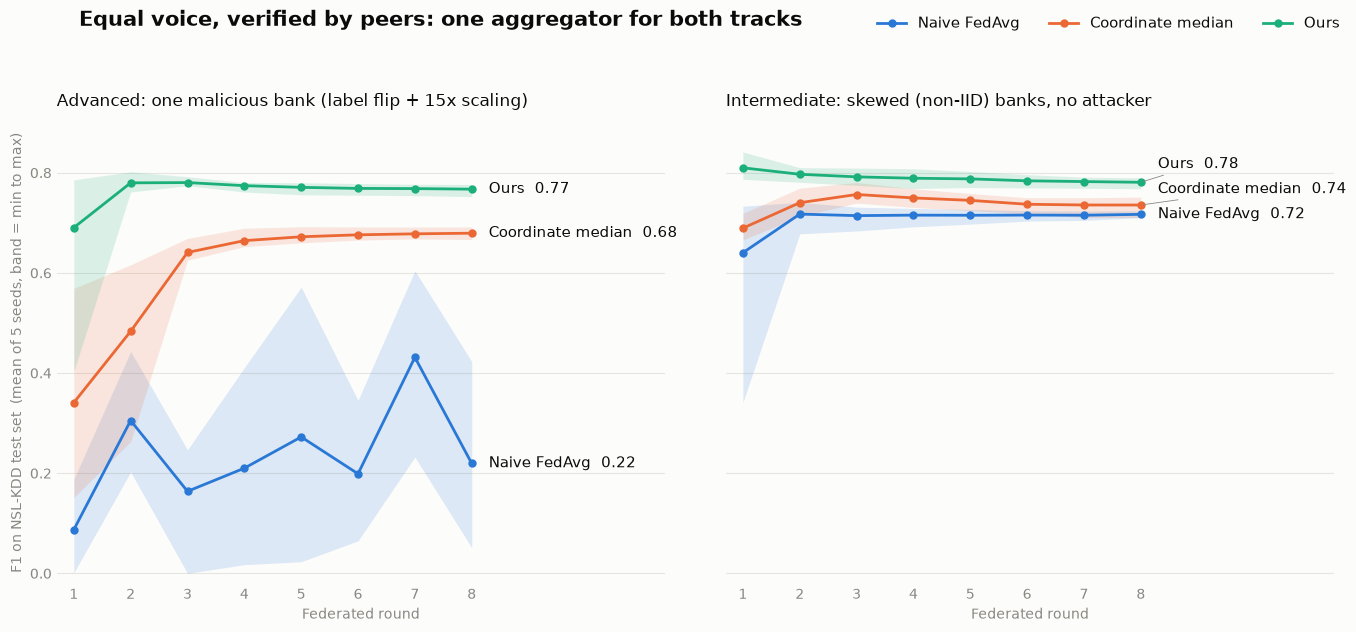

In [14]:
# Cover image: F1 by round, mean of 5 seeds (band = min..max across seeds)
import matplotlib.pyplot as plt
INK, MUTED, SURF = "#0b0b0b", "#898781", "#fcfcfb"
C = {"Naive FedAvg": "#2a78d6", "Coordinate median": "#eb6834", "Ours": "#1baf7a"}
panels = [
    ("Advanced: one malicious bank (label flip + 15x scaling)", ADV["OFFICIAL: bank 1, flip + 15x scale"]),
    ("Intermediate: skewed (non-IID) banks, no attacker",
     {"Naive FedAvg": INT["Naive FedAvg (BEFORE)"], "Coordinate median": INT["Coordinate median (provided)"], "Ours": INT["Ours (AFTER)"]}),
]
fig, axes = plt.subplots(1, 2, figsize=(14, 6.4), sharey=True, facecolor=SURF)
x = np.arange(1, 9)
for ax, (title, series) in zip(axes, panels):
    ax.set_facecolor(SURF)
    for k, a in series.items():
        ax.fill_between(x, a.min(0), a.max(0), color=C[k], alpha=0.15, lw=0, zorder=2)
        ax.plot(x, a.mean(0), color=C[k], lw=2, marker="o", ms=5, label=k, zorder=3)
    last = -1
    for y, k in sorted((a[:, -1].mean(), k) for k, a in series.items()):   # direct labels, nudged apart
        ly = max(y, last + 0.05); last = ly
        ax.annotate(f"{k}  {y:.2f}", (8, y), xytext=(8.3, ly), color=INK, fontsize=10.5, va="center",
                    arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.6) if abs(ly - y) > 0.01 else None)
    ax.set_title(title, color=INK, fontsize=12.5, loc="left", pad=12)
    ax.set_xlabel("Federated round", color=MUTED); ax.set_xlim(0.7, 11.4); ax.set_xticks(x); ax.set_ylim(-0.02, 0.9)
    ax.grid(axis="y", color="#e6e5e0", lw=0.8); ax.tick_params(colors=MUTED, length=0)
    for s in ax.spines.values(): s.set_visible(False)
axes[0].set_ylabel("F1 on NSL-KDD test set  (mean of 5 seeds, band = min to max)", color=MUTED)
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, loc="upper right", bbox_to_anchor=(0.97, 0.99), ncol=3, fontsize=10.5, labelcolor=INK)
fig.suptitle("Equal voice, verified by peers: one aggregator for both tracks", color=INK, fontsize=15, x=0.06, ha="left", weight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93)); fig.savefig("cover.png", dpi=150, facecolor=SURF); plt.show()

### Results summary

In [15]:
# Every headline number in our Writeup, in one place
o = ADV["OFFICIAL: bank 1, flip + 15x scale"]
print("ADVANCED (primary) — official attack, same split/model/rounds")
print(f"  seed 42 (exported model): naive {attacked_history[-1]['f1']:.4f} -> ours {my_defense_history[-1]['f1']:.4f}   recovered +{my_defense_history[-1]['f1'] - attacked_history[-1]['f1']:.4f}   (median {defended_history[-1]['f1']:.4f})")
print(f"  5 seeds:                  naive {ms(o['Naive FedAvg'])} -> ours {ms(o['Ours'])}   recovered +{o['Ours'][:, -1].mean() - o['Naive FedAvg'][:, -1].mean():.4f}   (median {ms(o['Coordinate median'])})")
print("INTERMEDIATE (supporting) — non-IID, no attacker")
print(f"  seed 42:                  naive {noniid_history[-1]['f1']:.4f} -> ours {custom_history[-1]['f1']:.4f}   gain +{custom_history[-1]['f1'] - noniid_history[-1]['f1']:.4f}")
print(f"  5 seeds:                  naive {ms(INT['Naive FedAvg (BEFORE)'])} -> ours {ms(INT['Ours (AFTER)'])}   gain +{INT['Ours (AFTER)'][:, -1].mean() - INT['Naive FedAvg (BEFORE)'][:, -1].mean():.4f}")

ADVANCED (primary) — official attack, same split/model/rounds
  seed 42 (exported model): naive 0.0511 -> ours 0.7760   recovered +0.7249   (median 0.6855)
  5 seeds:                  naive 0.2194 ± 0.1190 -> ours 0.7672 ± 0.0100   recovered +0.5478   (median 0.6793 ± 0.0092)
INTERMEDIATE (supporting) — non-IID, no attacker
  seed 42:                  naive 0.7117 -> ours 0.7821   gain +0.0704
  5 seeds:                  naive 0.7169 ± 0.0057 -> ours 0.7809 ± 0.0072   gain +0.0641


---
## 8. Submission (rubric-graded, no Kaggle leaderboard)

Run this to export your final model. Pick whichever result (intermediate aggregation or
advanced defense) you want judged — set `TRACK` and `FINAL_MODEL` accordingly.

**Input contract:** your exported model's `forward(x)` must accept the standard 41-column
preprocessed feature tensor exactly as produced in Section 1 (`FEATURE_COLS`, same order,
same scaling). If you did feature engineering, build it as extra layers *inside* your model
rather than as a separate preprocessing step.


In [16]:

TEAM_NAME = "ZeroTrustAI"
TRACK = "advanced"  # "intermediate" or "advanced"
FINAL_MODEL = my_defense_model  # <- point this at whichever model you want submitted

final_metrics = evaluate(FINAL_MODEL)

FINAL_MODEL.eval()
scripted = torch.jit.script(FINAL_MODEL)
scripted.save("model_scripted.pt")

submission = {
    "team_name": TEAM_NAME,
    "track": TRACK,
    "self_reported_metrics": final_metrics,
    "model_file": "model_scripted.pt",
    "n_input_features": N_FEATURES,
}
with open("submission.json", "w") as f:
    json.dump(submission, f, indent=2)

print(json.dumps(submission, indent=2))
print("\\nInclude model_scripted.pt and submission.json in your GitHub repo (your Writeup's Project Link).")


{
  "team_name": "ZeroTrustAI",
  "track": "advanced",
  "self_reported_metrics": {
    "precision": 0.925,
    "recall": 0.6684,
    "f1": 0.776
  },
  "model_file": "model_scripted.pt",
  "n_input_features": 41
}
\nInclude model_scripted.pt and submission.json in your GitHub repo (your Writeup's Project Link).


/Users/kelvinackah/Desktop/projects/hackaton/secure-ai-competition/.venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


### What to hand in
1. Your Kaggle Writeup — include the before/after F1 comparison for whichever track(s) you
   attempted, this is your primary evidence for the Automated Detection Score.
2. Your GitHub repo (Project Link) containing `model_scripted.pt`, `submission.json`, and
   this notebook, fully run.
3. Cover image, video (≤3 min), all per the Submission Requirements.
4. Be ready to demo live on Day 7.
